In [27]:
import json
from glob import glob as glob
import pandas as pd
import os
from tqdm import tqdm as tqdm 
from pathlib import Path
import numpy as np

In [4]:
with open("eval_results.zip", "r") as f:
    data = json.load(f)

In [7]:
!unzip eval_results.zip

Archive:  eval_results.zip
   creating: eval_results_lite_CrossSession/
   creating: eval_results_lite_CrossSession/linear_laplacian-stft_abs_nperseg512_poverlap0.75_maxfreq150/
  inflating: eval_results_lite_CrossSession/linear_laplacian-stft_abs_nperseg512_poverlap0.75_maxfreq150/population_btbank10_1_word_length.json  
  inflating: eval_results_lite_CrossSession/linear_laplacian-stft_abs_nperseg512_poverlap0.75_maxfreq150/population_btbank3_0_delta_volume.json  
  inflating: eval_results_lite_CrossSession/linear_laplacian-stft_abs_nperseg512_poverlap0.75_maxfreq150/population_btbank3_1_onset.json  
  inflating: eval_results_lite_CrossSession/linear_laplacian-stft_abs_nperseg512_poverlap0.75_maxfreq150/population_btbank3_0_pitch.json  
  inflating: eval_results_lite_CrossSession/linear_laplacian-stft_abs_nperseg512_poverlap0.75_maxfreq150/population_btbank1_1_gpt2_surprisal.json  
  inflating: eval_results_lite_CrossSession/linear_laplacian-stft_abs_nperseg512_poverlap0.75_maxfreq150

In [13]:
cat eval_results_lite_CrossSubject/linear_laplacian-stft_abs_nperseg512_poverlap0.75_maxfreq150/population_btbank10_0_word_head_pos.json

{
    "model_name": "Logistic Regression",
    "author": "Andrii Zahorodnii",
    "description": "Simple Logistic Regression using all electrodes (laplacian-stft_abs).",
    "organization": "MIT",
    "organization_url": "https://azaho.org/",
    "timestamp": 1763588047.631291,
    "evaluation_results": {
        "btbank10_0": {
            "population": {
                "time_bins": [],
                "one_second_after_onset": {
                    "time_bin_start": 0.0,
                    "time_bin_end": 1.0,
                    "folds": [
                        {
                            "train_accuracy": 1.0,
                            "train_roc_auc": 1.0,
                            "test_accuracy": 0.5148571428571429,
                            "test_roc_auc": 0.5093022040816326
                        }
                    ]
                }
            }
        }
    },
    "config": {
        "preprocess": {
            "type": "laplacian-stft_abs",
            "st

In [25]:


def get_test_results(results, eval_name):
    eval_results = results["evaluation_results"]
    assert len(eval_results.keys()) == 1
    records = []
    for subject_trial in eval_results:
        subject = subject_trial.split("_")[0][len("btbank"):]
        trial = subject_trial.split("_")[1]
        # subject_trial_results = eval_results[subject_trial]['electrode']
        subject_trial_results = eval_results[subject_trial]['population']
        # for electrode in subject_trial_results:
        electrode_results = subject_trial_results
        time_bin_results = electrode_results["one_second_after_onset"]
        # for time_bin in time_bin_results:
        # time_bin_start = time_bin['one_second_after_onset']
        fold_results = time_bin_results['folds']
        avg_test = np.mean([f['test_roc_auc'] for f in fold_results])
        records.append({
            "subject": subject,
            "trial": trial,
            "ID": f'sub_{subject}',
            # "electrode": electrode,
            "avg_test": avg_test,
            # "time_bin": time_bin_start,
            "task": eval_name
        })
        return records



In [29]:
all_records = []

results_root = f"/storage/czw/neuroprobe/eval_results_lite_CrossSubject/linear_laplacian-stft_abs_nperseg512_poverlap0.75_maxfreq150/"
all_results_paths = glob(os.path.join(results_root, "*.json"))
for path in tqdm(all_results_paths):
    name = Path(path).stem
    sub_id = name.split("_")[1][len("btbank"):]
    trial_id = name.split("_")[2]
    eval_name = "_".join(name.split("_")[3:])
    with open(path, "r") as f:
        results = json.load(f)
        test_results = get_test_results(results, eval_name)
    all_records += test_results
    
results_df = pd.DataFrame.from_records(all_records)



100%|████████████████████████████████████████████████████████████████████████████████| 150/150 [00:00<00:00, 3648.93it/s]


In [40]:
results_df

,subject,trial,ID,avg_test,task
0,7,1,sub_7,0.504605,global_flow
1,7,0,sub_7,0.496520,gpt2_surprisal
2,7,1,sub_7,0.501277,frame_brightness
3,10,0,sub_10,0.539946,word_index
4,10,0,sub_10,0.500886,word_gap
...,...,...,...,...,...
145,7,1,sub_7,0.501121,gpt2_surprisal
146,4,0,sub_4,0.494193,pitch
147,3,0,sub_3,0.510995,local_flow
148,4,0,sub_4,0.508813,local_flow


In [47]:
means = results_df.groupby("ID")["avg_test"].mean().to_frame()

In [48]:
means

,avg_test
ID,
sub_1,0.578849
sub_10,0.517130
sub_3,0.540566
sub_4,0.558096
sub_7,0.501422


In [33]:
data_root = "/storage/czw/braintreebank_data/"
localization_root = os.path.join(data_root, "localization")
all_localization_dfs = {}
for fpath in glob(f'{localization_root}/sub_*/*.csv'):
    subject = fpath.split("/")[-2]
    local_df = pd.read_csv(fpath)
    # local_df["common_name"] = [dk2region(x) for x in local_df.DesikanKilliany]
    all_localization_dfs[subject] = local_df

In [58]:

sub_i = "sub_4"
ious = {}
# for sub_i in sorted(all_localization_dfs):
for sub_j in sorted(means.index):
    local_df_i = all_localization_dfs[sub_i]
    regions_i = set(local_df_i.DesikanKilliany)
    local_df_j = all_localization_dfs[sub_j]
    regions_j = set(local_df_j.DesikanKilliany)

    iou = len(regions_i.intersection(regions_j))/len(regions_i.union(regions_j))
    ious[sub_j] = iou
    means.loc[sub_j, "iou"] = iou



In [59]:
ious

{'sub_1': 0.041666666666666664,
 'sub_10': 0.07142857142857142,
 'sub_3': 0.37142857142857144,
 'sub_4': 1.0,
 'sub_7': 0.47619047619047616}

In [60]:
means

,avg_test,iou
ID,,
sub_1,0.578849,0.041667
sub_10,0.517130,0.071429
sub_3,0.540566,0.371429
sub_4,0.558096,1.000000
sub_7,0.501422,0.476190


In [61]:
import seaborn as sns

<Axes: xlabel='iou', ylabel='avg_test'>

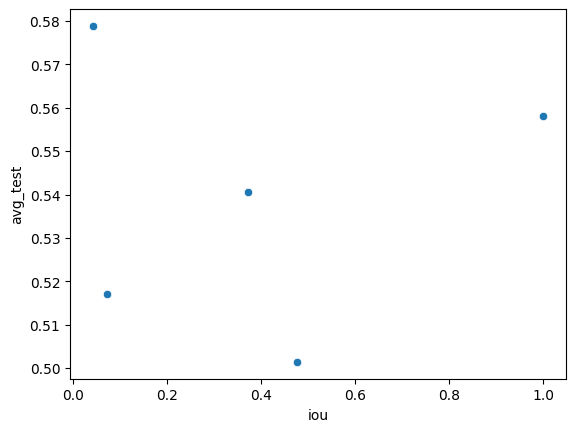

In [62]:
sns.scatterplot(data=means, x="iou", y="avg_test")